--README--

To run the code in this notebook, you must move the entire 'yelp' folder into your 'My Drive'.

In [1]:
# connecting to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# getting yelp dataset
import json
import pandas as pd

# Paste the copied path here
file_path = '/content/drive/MyDrive/yelp/yelp_academic_dataset_business.json'

data = []
with open(file_path, 'r') as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)
display(df.head())


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [3]:
df['city']

,city
0,Santa Barbara
1,Affton
2,Tucson
3,Philadelphia
4,Green Lane
...,...
150341,Edmonton
150342,Nashville
150343,Indianapolis
150344,Edwardsville


In [4]:
# getting only coffee shops
coffee_df = df[df['categories'].str.contains('Coffee & Tea', na=False)]
print(coffee_df.head())

               business_id                             name  \
3   MTSW4McQd7CbVtyjqoe9mw               St Honore Pastries   
20  WKMJwqnfZKsAae75RMP6jA   Roast Coffeehouse and Wine Bar   
46  JX4tUpd09YFchLBuI43lGw  Naked Cyber Cafe & Espresso Bar   
47  lk9IwjZXqUMqqOhM774DtQ                 Caviar & Bananas   
53  cVBxfMC4lp3DnocjYA3FHQ                Paws The Cat Cafe   

                 address          city state postal_code   latitude  \
3            935 Race St  Philadelphia    PA       19107  39.955505   
20   10359 104 Street NW      Edmonton    AB     T5J 1B9  53.546045   
46  10303  108 Street NW      Edmonton    AB     T5J 1L7  53.544682   
47         2031 Broadway     Nashville    TN       37203  36.148371   
53      10588 109 Street      Edmonton    AB     T5H 3B2  53.549633   

     longitude  stars  review_count  is_open  \
3   -75.155564    4.0            80        1   
20 -113.499169    4.0            40        0   
46 -113.506589    4.0            12        1   
47

In [5]:
# replacing state abbreviations with state names

# Dictionary mapping state abbreviations to full names (Title Case)
state_abbrev_to_name = {
    'AL': 'Alabama','AK': 'Alaska','AZ': 'Arizona','AR': 'Arkansas','CA': 'California','CO': 'Colorado',
    'CT': 'Connecticut','DE': 'Delaware','FL': 'Florida','GA': 'Georgia','HI': 'Hawaii','ID': 'Idaho',
    'IL': 'Illinois','IN': 'Indiana','IA': 'Iowa','KS': 'Kansas','KY': 'Kentucky','LA': 'Louisiana',
    'ME': 'Maine','MD': 'Maryland','MA': 'Massachusetts','MI': 'Michigan','MN': 'Minnesota','MS': 'Mississippi',
    'MO': 'Missouri','MT': 'Montana','NE': 'Nebraska','NV': 'Nevada','NH': 'New Hampshire','NJ': 'New Jersey',
    'NM': 'New Mexico','NY': 'New York','NC': 'North Carolina','ND': 'North Dakota','OH': 'Ohio',
    'OK': 'Oklahoma','OR': 'Oregon','PA': 'Pennsylvania','RI': 'Rhode Island','SC': 'South Carolina',
    'SD': 'South Dakota','TN': 'Tennessee','TX': 'Texas','UT': 'Utah','VT': 'Vermont','VA': 'Virginia',
    'WA': 'Washington','WV': 'West Virginia','WI': 'Wisconsin','WY': 'Wyoming','DC': 'District of Columbia'
}

# cleaning state abbreviation
coffee_df["state"] = coffee_df["state"].str.strip().str.upper()

# Replace abbreviations with full state names where possible
coffee_df["state"] = coffee_df["state"].map(state_abbrev_to_name)

# dropping states that aren't in US (e.g. "AB")
coffee_df = coffee_df.dropna(subset=["state"])

print(coffee_df.head())


               business_id                  name                address  \
3   MTSW4McQd7CbVtyjqoe9mw    St Honore Pastries            935 Race St   
47  lk9IwjZXqUMqqOhM774DtQ      Caviar & Bananas          2031 Broadway   
82  ppFCk9aQkM338Rgwpl2F5A                  Wawa       3604 Chestnut St   
85  IDtLPgUrqorrpqSLdfMhZQ  Helena Avenue Bakery  131 Anacapa St, Ste C   
89  oaboaRBUgGjbo2kfUIKDLQ      Mike's Ice Cream          129 2nd Ave N   

             city         state postal_code   latitude   longitude  stars  \
3    Philadelphia  Pennsylvania       19107  39.955505  -75.155564    4.0   
47      Nashville     Tennessee       37203  36.148371  -86.798895    3.5   
82   Philadelphia  Pennsylvania       19104  39.954573  -75.194894    3.0   
85  Santa Barbara    California       93101  34.414445 -119.690672    4.0   
89      Nashville     Tennessee       37201  36.162649  -86.775973    4.5   

    review_count  is_open                                         attributes  \
3     

/tmp/ipython-input-2007539056.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coffee_df["state"] = coffee_df["state"].str.strip().str.upper()
/tmp/ipython-input-2007539056.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coffee_df["state"] = coffee_df["state"].map(state_abbrev_to_name)


In [6]:
print(f"Original data count: {len(df)}") # Assuming you saved the original dataframe
print(f"Cleaned data count: {len(coffee_df)}")

# Check which states are left to ensure no strange NaN values appeared
print(coffee_df['state'].unique())

Original data count: 150346
Cleaned data count: 6325
['Pennsylvania' 'Tennessee' 'California' 'Missouri' 'Florida' 'Louisiana'
 'New Jersey' 'Indiana' 'Nevada' 'Idaho' 'Arizona' 'Illinois' 'Delaware'
 'North Carolina']


In [7]:
# getting city_to_county dataset
city_to_county_df = pd.read_csv('/content/drive/MyDrive/yelp/city_to_county.csv')
print(city_to_county_df.head())

          city   city_ascii state_id  state_name  county_fips  county_name  \
0     New York     New York       NY    New York        36081       Queens   
1  Los Angeles  Los Angeles       CA  California         6037  Los Angeles   
2      Chicago      Chicago       IL    Illinois        17031         Cook   
3        Miami        Miami       FL     Florida        12086   Miami-Dade   
4      Houston      Houston       TX       Texas        48201       Harris   

       lat       lng  population  density source  military  incorporated  \
0  40.6943  -73.9249    18832416  10943.7  shape     False          True   
1  34.1141 -118.4068    11885717   3165.7  shape     False          True   
2  41.8375  -87.6866     8489066   4590.3  shape     False          True   
3  25.7840  -80.2101     6113982   4791.1  shape     False          True   
4  29.7860  -95.3885     6046392   1386.2  shape     False          True   

              timezone  ranking  \
0     America/New_York        1   
1  A

In [8]:
# getting county_to_party dataset
county_to_party_df = pd.read_csv('/content/drive/MyDrive/yelp/county_to_party.csv')
print(county_to_party_df.head())

  state_name  county_fips     county_name  votes_gop  votes_dem  total_votes  \
0    Alabama         1001  Autauga County      20484       7439        28190   
1    Alabama         1003  Baldwin County      95798      24934       121808   
2    Alabama         1005  Barbour County       5606       4158         9832   
3    Alabama         1007     Bibb County       7572       1619         9241   
4    Alabama         1009   Blount County      25354       2576        28115   

      diff   per_gop   per_dem  per_point_diff  
0  13045.0  0.726641  0.263888        0.462753  
1  70864.0  0.786467  0.204699        0.581768  
2   1448.0  0.570179  0.422905        0.147274  
3   5953.0  0.819392  0.175197        0.644194  
4  22778.0  0.901796  0.091624        0.810173  


In [9]:
# adding party column to county_to_party
import numpy as np

county_to_party_df["party"] = np.where(
    county_to_party_df["votes_gop"] > county_to_party_df["votes_dem"], "Republican", "Democrat"
)

print(county_to_party_df.head())

  state_name  county_fips     county_name  votes_gop  votes_dem  total_votes  \
0    Alabama         1001  Autauga County      20484       7439        28190   
1    Alabama         1003  Baldwin County      95798      24934       121808   
2    Alabama         1005  Barbour County       5606       4158         9832   
3    Alabama         1007     Bibb County       7572       1619         9241   
4    Alabama         1009   Blount County      25354       2576        28115   

      diff   per_gop   per_dem  per_point_diff       party  
0  13045.0  0.726641  0.263888        0.462753  Republican  
1  70864.0  0.786467  0.204699        0.581768  Republican  
2   1448.0  0.570179  0.422905        0.147274  Republican  
3   5953.0  0.819392  0.175197        0.644194  Republican  
4  22778.0  0.901796  0.091624        0.810173  Republican  


In [10]:
# sanity check: party count
county_to_party_df["party"].value_counts()


,count
party,
Republican,2685
Democrat,475


In [11]:
# getting rid of 'county' in county_name
county_to_party_df["county_name"] = county_to_party_df["county_name"].str.replace(" County", "", regex=False)
print(county_to_party_df.head())

  state_name  county_fips county_name  votes_gop  votes_dem  total_votes  \
0    Alabama         1001     Autauga      20484       7439        28190   
1    Alabama         1003     Baldwin      95798      24934       121808   
2    Alabama         1005     Barbour       5606       4158         9832   
3    Alabama         1007        Bibb       7572       1619         9241   
4    Alabama         1009      Blount      25354       2576        28115   

      diff   per_gop   per_dem  per_point_diff       party  
0  13045.0  0.726641  0.263888        0.462753  Republican  
1  70864.0  0.786467  0.204699        0.581768  Republican  
2   1448.0  0.570179  0.422905        0.147274  Republican  
3   5953.0  0.819392  0.175197        0.644194  Republican  
4  22778.0  0.901796  0.091624        0.810173  Republican  


In [12]:
# joining tables together

import pandas as pd
import numpy as np
import re

# --- Helpers
def std_col(s: pd.Series) -> pd.Series:
    return (s.astype(str)
             .str.strip()
             .str.title()
             .str.normalize('NFKD')
             .str.encode('ascii', 'ignore')
             .str.decode('ascii'))

def clean_county_name(s: pd.Series) -> pd.Series:
    # Normalize then remove spaces/hyphens/apostrophes/periods; drop "County" if present anywhere
    s = std_col(s)
    s = s.str.replace(" County", "", regex=False)
    s = s.str.replace(r"[ \-'\.]", "", regex=True)
    return s

# --- 0) Copies + row id to restore original order
coffee = coffee_df.copy()
coffee["__row"] = np.arange(len(coffee))

# =========================
# 1) Prep coffee_df
# =========================
coffee["city_std"]  = std_col(coffee["city"])        # e.g., "Philadelphia"
coffee["state_std"] = std_col(coffee["state"])       # e.g., "Pennsylvania"

# Alias mapping for hard-to-match city/state pairs → their parent city/county equivalents
city_alias = {
    # --- Missouri ---
    ("Saint Louis", "Missouri"): ("Saint Louis", "Missouri"),   # Independent city
    ("St Louis", "Missouri"): ("Saint Louis", "Missouri"),
    ("Saint Charles", "Missouri"): ("Saint Charles", "Missouri"),

    # --- Florida ---
    ("Saint Petersburg", "Florida"): ("Saint Petersburg", "Florida"),
    ("St Petersburg", "Florida"): ("Saint Petersburg", "Florida"),

    # --- Louisiana ---
    # (none listed this round, but keep Jefferson/New Orleans logic if you had those earlier)

    # --- New Jersey (Camden/Burlington counties) ---
    ("Cherry Hill", "New Jersey"): ("Camden", "New Jersey"),
    ("Collingswood", "New Jersey"): ("Camden", "New Jersey"),
    ("Haddonfield", "New Jersey"): ("Camden", "New Jersey"),
    ("Pennsauken", "New Jersey"): ("Camden", "New Jersey"),
    ("Mount Laurel", "New Jersey"): ("Burlington", "New Jersey"),
    ("Burlington", "New Jersey"): ("Burlington", "New Jersey"),

    # --- Pennsylvania suburbs (Bucks, Delaware, Montgomery counties) ---
    ("Doylestown", "Pennsylvania"): ("Bucks", "Pennsylvania"),
    ("Bensalem", "Pennsylvania"): ("Bucks", "Pennsylvania"),
    ("Bristol", "Pennsylvania"): ("Bucks", "Pennsylvania"),
    ("Havertown", "Pennsylvania"): ("Delaware", "Pennsylvania"),
    ("Upper Darby", "Pennsylvania"): ("Delaware", "Pennsylvania"),
    ("Springfield", "Pennsylvania"): ("Delaware", "Pennsylvania"),
    ("East Norriton", "Pennsylvania"): ("Montgomery", "Pennsylvania"),
    ("Horsham", "Pennsylvania"): ("Montgomery", "Pennsylvania"),

    # --- Tennessee ---
    ("Hermitage", "Tennessee"): ("Davidson", "Tennessee"),  # Nashville area
}

# Function to apply aliases to standardized columns
def apply_city_alias(df, alias_map):
    new_city, new_state = [], []
    for c, s in zip(df["city_std"], df["state_std"]):
        if (c, s) in alias_map:
            mapped_city, mapped_state = alias_map[(c, s)]
            new_city.append(mapped_city)
            new_state.append(mapped_state)
        else:
            new_city.append(c)
            new_state.append(s)
    df["city_std"] = new_city
    df["state_std"] = new_state
    return df

# Apply alias correction to coffee_df BEFORE city→county merge
coffee = apply_city_alias(coffee, city_alias)

# =========================
# 2) Prep city_to_county_df (uses full state names already)
# =========================
cty = city_to_county_df.copy()
cty["city_std"]   = std_col(cty["city"])
cty["state_std"]  = std_col(cty["state_name"])
cty["county_std"] = clean_county_name(cty["county_name"])  # "Miami-Dade" -> "MiamiDade"

# If a city spans multiple counties, keep the largest population county
cty = cty.sort_values(["city_std","state_std","population"], ascending=[True,True,False])
city2county = cty.drop_duplicates(subset=["city_std","state_std"], keep="first")[
    ["city_std","state_std","county_std","county_name"]
]

# =========================
# 3) Prep county_to_party_df (your county_name is already stripped, e.g., "Autauga")
# =========================
c2p = county_to_party_df.copy()
c2p["state_std"]  = std_col(c2p["state_name"])
c2p["county_std"] = clean_county_name(c2p["county_name"])
county_party = c2p[["state_std","county_std","party"]].drop_duplicates()

# =========================
# 4) coffee (city,state) -> county (using FIPS)
# =========================
coffee_cc = coffee.merge(
    city2county,
    on=["city_std", "state_std"],
    how="left",
    validate="m:1"
)

# =========================
# 5) county -> party
# =========================
coffee_with_party = coffee_cc.merge(
    county_party,
    on=["state_std", "county_std"],
    how="left",
    validate="m:1"
)

# =========================
# 6) Clean up + result
# =========================
final = (coffee_with_party
         .sort_values("__row")
         .drop(columns=["__row","city_std","state_std"], errors="ignore"))

# final now has all original coffee_df columns + county_name (from city_to_county) + party (from county_to_party)
print(final.head())
print(final.info())


              business_id                  name                address  \
0  MTSW4McQd7CbVtyjqoe9mw    St Honore Pastries            935 Race St   
1  lk9IwjZXqUMqqOhM774DtQ      Caviar & Bananas          2031 Broadway   
2  ppFCk9aQkM338Rgwpl2F5A                  Wawa       3604 Chestnut St   
3  IDtLPgUrqorrpqSLdfMhZQ  Helena Avenue Bakery  131 Anacapa St, Ste C   
4  oaboaRBUgGjbo2kfUIKDLQ      Mike's Ice Cream          129 2nd Ave N   

            city         state postal_code   latitude   longitude  stars  \
0   Philadelphia  Pennsylvania       19107  39.955505  -75.155564    4.0   
1      Nashville     Tennessee       37203  36.148371  -86.798895    3.5   
2   Philadelphia  Pennsylvania       19104  39.954573  -75.194894    3.0   
3  Santa Barbara    California       93101  34.414445 -119.690672    4.0   
4      Nashville     Tennessee       37201  36.162649  -86.775973    4.5   

   review_count  is_open                                         attributes  \
0            80    

In [13]:
# Check how many businesses were successfully linked to a political party (Party is not NaN)
print("Number of successful party matches:", final['party'].notna().sum())
print("Number of missing party info:", final['party'].isna().sum())

# Check the final distribution of parties
print(final['party'].value_counts())

Number of successful party matches: 5136
Number of missing party info: 1189
party
Democrat      3394
Republican    1742
Name: count, dtype: int64


In [14]:
# Create a list of unique cities by keeping both City and State
unique_cities_df = final[['city', 'state']].drop_duplicates().sort_values(['state', 'city'])

# Print the total count
print(f"Total number of unique cities: {len(unique_cities_df)}")

# Display the list
display(unique_cities_df)

Total number of unique cities: 522


,city,state
1076,Casa Adobes,Arizona
6087,Catalina,Arizona
1247,Corona de Tucson,Arizona
6032,Green Valley,Arizona
123,Marana,Arizona
...,...,...
3044,Pleasant View,Tennessee
274,Smyrna,Tennessee
3048,Springfield,Tennessee
3141,White House,Tennessee


In [15]:
# dealing with cities with no party

# ------------------ START: City -> County -> Party Patch (complete block) ------------------
import pandas as pd
import numpy as np
import re

# ========= Helpers (updated) =========
def std_col(s: pd.Series) -> pd.Series:
    return (s.astype(str)
             .str.strip()
             .str.title()
             .str.normalize('NFKD')
             .str.encode('ascii','ignore')
             .str.decode('ascii'))

def std_city(s: pd.Series) -> pd.Series:
    # normalize city names more aggressively: remove dots/apostrophes; collapse spaces
    s = std_col(s)
    s = s.str.replace(r"[\.']", "", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True)
    return s

def clean_county_name(s: pd.Series) -> pd.Series:
    # remove common county-type suffixes (fixes LA Parishes, AK Boroughs, etc.)
    s = std_col(s)
    for suff in [" County", " Parish", " Borough", " Municipality", " City And Borough", " City"]:
        s = s.str.replace(suff, "", regex=False)
    # strip spaces, hyphens, apostrophes, periods
    s = s.str.replace(r"[ \-'\.]", "", regex=True)
    return s

# ========= Build county index (uses updated cleaners) =========
c2p = county_to_party_df.copy()
c2p["state_std"]  = std_col(c2p["state_name"])
c2p["county_std"] = clean_county_name(c2p["county_name"])
c2p["county_fips"] = c2p["county_fips"].astype(int)
county_index = c2p[["state_std","county_std","county_fips","party"]].drop_duplicates()
fips_to_party = dict(zip(c2p["county_fips"], c2p["party"]))

# ========= Direct city -> county_name overrides (expanded to cover your stragglers) =========
manual_rows = [
    # --- Missouri (STL region) ---
    {"city":"Saint Louis","state":"Missouri","county_name":"St. Louis City"},
    {"city":"St Louis","state":"Missouri","county_name":"St. Louis City"},
    {"city":"Saint Charles","state":"Missouri","county_name":"St. Charles"},
    {"city":"St Charles","state":"Missouri","county_name":"St. Charles"},
    {"city":"Earth City","state":"Missouri","county_name":"St. Louis"},
    {"city":"Peerless Park","state":"Missouri","county_name":"St. Louis"},
    {"city":"Blvd","state":"Missouri","county_name":"St. Louis"},

    # --- Florida (Pinellas / Hillsborough / Pasco) ---
    {"city":"Saint Petersburg","state":"Florida","county_name":"Pinellas"},
    {"city":"St Petersburg","state":"Florida","county_name":"Pinellas"},
    {"city":"St.Petersburg","state":"Florida","county_name":"Pinellas"},
    {"city":"Saint Pete Beach","state":"Florida","county_name":"Pinellas"},
    {"city":"St Pete Beach","state":"Florida","county_name":"Pinellas"},
    {"city":"Saint Petersburg Beach","state":"Florida","county_name":"Pinellas"},
    {"city":"Clearwater Beach","state":"Florida","county_name":"Pinellas"},
    {"city":"CLEARWATER BEACH","state":"Florida","county_name":"Pinellas"},
    {"city":"Pasadena","state":"Florida","county_name":"Pinellas"},   # South Pasadena
    {"city":"Petersburg","state":"Florida","county_name":"Pinellas"}, # malformed St Petersburg
    {"city":"Pinellas","state":"Florida","county_name":"Pinellas"},
    {"city":"Tampa Bay","state":"Florida","county_name":"Hillsborough"},
    {"city":"Greater Carrollwood","state":"Florida","county_name":"Hillsborough"},
    {"city":"Lithia","state":"Florida","county_name":"Hillsborough"},
    {"city":"Land O Lakes","state":"Florida","county_name":"Pasco"},
    {"city":"Land O'Lakes","state":"Florida","county_name":"Pasco"},

    # --- New Jersey (Burlington / Camden / Gloucester / Mercer / Salem) ---
    # Camden
    {"city":"Cherry Hill","state":"New Jersey","county_name":"Camden"},
    {"city":"Cherry Hil","state":"New Jersey","county_name":"Camden"},
    {"city":"Collingswood","state":"New Jersey","county_name":"Camden"},
    {"city":"Haddon Township","state":"New Jersey","county_name":"Camden"},
    {"city":"Haddonfield","state":"New Jersey","county_name":"Camden"},
    {"city":"Pennsauken","state":"New Jersey","county_name":"Camden"},
    {"city":"Gloucester Township","state":"New Jersey","county_name":"Camden"},
    {"city":"Berlin Township","state":"New Jersey","county_name":"Camden"},
    # Burlington
    {"city":"Burlington","state":"New Jersey","county_name":"Burlington"},
    {"city":"Mount Laurel","state":"New Jersey","county_name":"Burlington"},
    {"city":"Mt. Laurel","state":"New Jersey","county_name":"Burlington"},
    {"city":"Mt Laurel Twp, Nj","state":"New Jersey","county_name":"Burlington"},
    {"city":"Moorestown","state":"New Jersey","county_name":"Burlington"},
    {"city":"Medford","state":"New Jersey","county_name":"Burlington"},
    {"city":"Maple Shade","state":"New Jersey","county_name":"Burlington"},
    {"city":"Cinnaminson","state":"New Jersey","county_name":"Burlington"},
    {"city":"Delran","state":"New Jersey","county_name":"Burlington"},
    {"city":"Delran Twp","state":"New Jersey","county_name":"Burlington"},
    {"city":"Delanco","state":"New Jersey","county_name":"Burlington"},
    {"city":"Florence","state":"New Jersey","county_name":"Burlington"},
    {"city":"Edgewater Park","state":"New Jersey","county_name":"Burlington"},
    {"city":"Westampton","state":"New Jersey","county_name":"Burlington"},
    {"city":"Willingboro","state":"New Jersey","county_name":"Burlington"},
    {"city":"Lumberton","state":"New Jersey","county_name":"Burlington"},
    {"city":"Evesham","state":"New Jersey","county_name":"Burlington"},
    {"city":"Evesham Township","state":"New Jersey","county_name":"Burlington"},
    {"city":"Mansfield","state":"New Jersey","county_name":"Burlington"},
    {"city":"Pemberton","state":"New Jersey","county_name":"Burlington"},
    {"city":"Columbus","state":"New Jersey","county_name":"Burlington"},
    {"city":"Eastampton","state":"New Jersey","county_name":"Burlington"},
    {"city":"Eastampton Township","state":"New Jersey","county_name":"Burlington"},
    {"city":"Mount Holly","state":"New Jersey","county_name":"Burlington"},
    {"city":"Bordentown","state":"New Jersey","county_name":"Burlington"},
    # Gloucester
    {"city":"Deptford","state":"New Jersey","county_name":"Gloucester"},
    {"city":"Deptford Twp","state":"New Jersey","county_name":"Gloucester"},
    {"city":"Deptford Township","state":"New Jersey","county_name":"Gloucester"},
    {"city":"West Deptford","state":"New Jersey","county_name":"Gloucester"},
    {"city":"Logan Township","state":"New Jersey","county_name":"Gloucester"},
    {"city":"Washington Township","state":"New Jersey","county_name":"Gloucester"},
    {"city":"Harrison Township","state":"New Jersey","county_name":"Gloucester"},
    {"city":"Clarksboro","state":"New Jersey","county_name":"Gloucester"},
    # Mercer
    {"city":"Ewing","state":"New Jersey","county_name":"Mercer"},
    {"city":"Ewing Township","state":"New Jersey","county_name":"Mercer"},
    {"city":"Hamilton","state":"New Jersey","county_name":"Mercer"},
    {"city":"Lawrence Township","state":"New Jersey","county_name":"Mercer"},
    # Salem
    {"city":"Pennsville","state":"New Jersey","county_name":"Salem"},

    # --- Pennsylvania (Bucks / Delaware / Montgomery / Chester / Philadelphia) ---
    # Bucks
    {"city":"Doylestown","state":"Pennsylvania","county_name":"Bucks"},
    {"city":"Bensalem","state":"Pennsylvania","county_name":"Bucks"},
    {"city":"Bristol","state":"Pennsylvania","county_name":"Bucks"},
    {"city":"Buckingham","state":"Pennsylvania","county_name":"Bucks"},
    {"city":"Lahaska","state":"Pennsylvania","county_name":"Bucks"},
    {"city":"Pipersville","state":"Pennsylvania","county_name":"Bucks"},
    {"city":"Holland","state":"Pennsylvania","county_name":"Bucks"},
    {"city":"Jamison","state":"Pennsylvania","county_name":"Bucks"},
    {"city":"Warminster","state":"Pennsylvania","county_name":"Bucks"},
    {"city":"Warrington","state":"Pennsylvania","county_name":"Bucks"},
    {"city":"Upper Southampton Township","state":"Pennsylvania","county_name":"Bucks"},
    {"city":"Southampton","state":"Pennsylvania","county_name":"Bucks"},
    {"city":"Washington Crossing","state":"Pennsylvania","county_name":"Bucks"},
    {"city":"Fountainville","state":"Pennsylvania","county_name":"Bucks"},
    {"city":"Hilltown","state":"Pennsylvania","county_name":"Bucks"},
    {"city":"Feasterville-Trevose","state":"Pennsylvania","county_name":"Bucks"},
    # Delaware
    {"city":"Havertown","state":"Pennsylvania","county_name":"Delaware"},
    {"city":"Upper Darby","state":"Pennsylvania","county_name":"Delaware"},
    {"city":"Springfield","state":"Pennsylvania","county_name":"Delaware"},
    {"city":"Newtown Square","state":"Pennsylvania","county_name":"Delaware"},
    {"city":"Glen Mills","state":"Pennsylvania","county_name":"Delaware"},
    {"city":"Radnor","state":"Pennsylvania","county_name":"Delaware"},
    {"city":"Edgmont","state":"Pennsylvania","county_name":"Delaware"},
    {"city":"Essington","state":"Pennsylvania","county_name":"Delaware"},
    {"city":"Secane","state":"Pennsylvania","county_name":"Delaware"},
    {"city":"Concordville","state":"Pennsylvania","county_name":"Delaware"},
    {"city":"Garnet Valley","state":"Pennsylvania","county_name":"Delaware"},
    {"city":"Aston","state":"Pennsylvania","county_name":"Delaware"},
    {"city":"Primos","state":"Pennsylvania","county_name":"Delaware"},
    {"city":"Haverford","state":"Pennsylvania","county_name":"Delaware"},
    # Montgomery
    {"city":"Abington","state":"Pennsylvania","county_name":"Montgomery"},
    {"city":"Hatfield","state":"Pennsylvania","county_name":"Montgomery"},
    {"city":"Dresher","state":"Pennsylvania","county_name":"Montgomery"},
    {"city":"Zieglerville","state":"Pennsylvania","county_name":"Montgomery"},
    {"city":"Skippack","state":"Pennsylvania","county_name":"Montgomery"},
    {"city":"Lafayette Hill","state":"Pennsylvania","county_name":"Montgomery"},
    {"city":"Colmar","state":"Pennsylvania","county_name":"Montgomery"},
    {"city":"Limerick","state":"Pennsylvania","county_name":"Montgomery"},
    {"city":"Center Square","state":"Pennsylvania","county_name":"Montgomery"},
    {"city":"Cedars","state":"Pennsylvania","county_name":"Montgomery"},
    {"city":"Cheltenham","state":"Pennsylvania","county_name":"Montgomery"},
    {"city":"Cheltenham Township","state":"Pennsylvania","county_name":"Montgomery"},
    {"city":"Stowe","state":"Pennsylvania","county_name":"Montgomery"},
    # Chester
    {"city":"Chester Springs","state":"Pennsylvania","county_name":"Chester"},
    {"city":"Birchrunville","state":"Pennsylvania","county_name":"Chester"},
    # Philadelphia (neighborhoods)
    {"city":"Manayunk","state":"Pennsylvania","county_name":"Philadelphia"},

    # --- Tennessee (Nashville / Davidson + Wilson) ---
    {"city":"Bellevue","state":"Tennessee","county_name":"Davidson"},
    {"city":"Joelton","state":"Tennessee","county_name":"Davidson"},
    {"city":"Hermitage","state":"Tennessee","county_name":"Davidson"},
    {"city":"Antioch","state":"Tennessee","county_name":"Davidson"},
    {"city":"Madison","state":"Tennessee","county_name":"Davidson"},
    {"city":"Old Hickory","state":"Tennessee","county_name":"Davidson"},
    {"city":"Mt. Juliet","state":"Tennessee","county_name":"Wilson"},
    {"city":"Mt Juliet","state":"Tennessee","county_name":"Wilson"},
    {"city":"East Nashville","state":"Tennessee","county_name":"Davidson"},

    # --- Delaware ---
    {"city":"Talleyville","state":"Delaware","county_name":"New Castle"},
    {"city":"Stanton","state":"Delaware","county_name":"New Castle"},

    # --- Illinois (near STL) ---
    {"city":"Cahokia","state":"Illinois","county_name":"St. Clair"},

    # --- Indiana ---
    {"city":"Camby","state":"Indiana","county_name":"Marion"},

    # --- Arizona ---
    {"city":"Casa Adobes","state":"Arizona","county_name":"Pima"},

    # --- Nevada ---
    {"city":"Vc Highlands","state":"Nevada","county_name":"Storey"},

    # --- Louisiana (Parish handling via cleaner) ---
    {"city":"Bywater","state":"Louisiana","county_name":"Orleans"},
    {"city":"Belle Chase","state":"Louisiana","county_name":"Plaquemines"},
]

manual = pd.DataFrame(manual_rows)
manual["city_std"]   = std_city(manual["city"])
manual["state_std"]  = std_col(manual["state"])
manual["county_std"] = clean_county_name(manual["county_name"])
manual = manual.drop_duplicates(subset=["city_std","state_std"])

# county name -> FIPS/party
manual_resolved = manual.merge(
    county_index, on=["state_std","county_std"], how="left"
)

# ========= Patch rows with NaN party (index-safe) =========
work = final.copy()
work["city_std"]  = std_city(work["city"])
work["state_std"] = std_col(work["state"])

mask = work["party"].isna()
sub = work.loc[mask, ["city_std","state_std"]].copy()
sub["__idx"] = sub.index

sub = sub.merge(
    manual_resolved[["city_std","state_std","county_fips","party"]],
    on=["city_std","state_std"], how="left"
)

hit = sub["county_fips"].notna()
if hit.any():
    work.loc[sub.loc[hit, "__idx"], "county_fips"] = sub.loc[hit, "county_fips"].astype(int).values
    work.loc[sub.loc[hit, "__idx"], "party"]       = sub.loc[hit, "party"].values

final_fixed = work.drop(columns=["city_std","state_std"], errors="ignore")

# ========= Report =========
total_unmatched_before = final["party"].isna().sum()
total_unmatched_after  = final_fixed["party"].isna().sum()
print(f"Unmatched before: {total_unmatched_before} | after: {total_unmatched_after}")
print("Remaining unmatched (top 50):")
print(final_fixed[final_fixed["party"].isna()][["city","state"]].value_counts().head(50))
# ------------------ END: City -> County -> Party Patch ------------------


Unmatched before: 1189 | after: 504
Remaining unmatched (top 50):
city                    state       
New Orleans             Louisiana       318
Metairie                Louisiana        65
Kenner                  Louisiana        21
Gretna                  Louisiana        15
Harvey                  Louisiana        12
Voorhees                New Jersey        9
Marrero                 Louisiana         8
Chalmette               Louisiana         7
Huntingdon Valley       Pennsylvania      7
Jefferson               Louisiana         6
Harahan                 Louisiana         6
River Ridge             Louisiana         3
Voorhees Township       New Jersey        3
Terrytown               Louisiana         3
Belle Chasse            Louisiana         2
Arabi                   Louisiana         1
Avondale                Louisiana         1
Feasterville Trevose    Pennsylvania      1
Mantua Township         New Jersey        1
Landsdale               Pennsylvania      1
Holmes           

In [16]:
# ------------------ START: Final tiny patch for remaining unmatched ------------------
import pandas as pd

# Reuse your existing helpers if they’re still in scope; otherwise redefine:
def std_col(s: pd.Series) -> pd.Series:
    return (s.astype(str)
             .str.strip()
             .str.title()
             .str.normalize('NFKD')
             .str.encode('ascii','ignore')
             .str.decode('ascii'))

def std_city(s: pd.Series) -> pd.Series:
    s = std_col(s)
    s = s.str.replace(r"[\.']", "", regex=True)   # drop dots/apostrophes
    s = s.str.replace(r"\s+", " ", regex=True)    # collapse spaces
    return s

def clean_county_name(s: pd.Series) -> pd.Series:
    s = std_col(s)
    for suff in [" County", " Parish", " Borough", " Municipality", " City And Borough", " City"]:
        s = s.str.replace(suff, "", regex=False)
    s = s.str.replace(r"[ \-'\.]", "", regex=True)
    return s

# Build/ensure county_index exists (safe to rebuild)
c2p = county_to_party_df.copy()
c2p["state_std"]  = std_col(c2p["state_name"])
c2p["county_std"] = clean_county_name(c2p["county_name"])
c2p["county_fips"] = c2p["county_fips"].astype(int)
county_index = c2p[["state_std","county_std","county_fips","party"]].drop_duplicates()

# Only the still-unmatched pairs you listed:
extra_rows = [
    # New Jersey
    {"city":"Voorhees","state":"New Jersey","county_name":"Camden"},
    {"city":"Voorhees Township","state":"New Jersey","county_name":"Camden"},
    {"city":"Ewing Twp","state":"New Jersey","county_name":"Mercer"},
    {"city":"Gloucester","state":"New Jersey","county_name":"Camden"},   # Gloucester City is in Camden County
    {"city":"Mantua Township","state":"New Jersey","county_name":"Gloucester"},
    {"city":"Southampton Township","state":"New Jersey","county_name":"Burlington"},
    {"city":"Woolwich Township","state":"New Jersey","county_name":"Gloucester"},
    {"city":"Woolwich Twp.","state":"New Jersey","county_name":"Gloucester"},

    # Pennsylvania
    {"city":"Huntingdon Valley","state":"Pennsylvania","county_name":"Montgomery"}, # (parts in Bucks too; Montco ok)
    {"city":"Feasterville Trevose","state":"Pennsylvania","county_name":"Bucks"},   # space variant
    {"city":"Landsdale","state":"Pennsylvania","county_name":"Montgomery"},         # typo of Lansdale
    {"city":"Holmes","state":"Pennsylvania","county_name":"Delaware"},
    {"city":"Southwest Philadelphia","state":"Pennsylvania","county_name":"Philadelphia"},
    {"city":"West Philadelphia","state":"Pennsylvania","county_name":"Philadelphia"},

    # Florida
    {"city":"Saint Petersburg Beach","state":"Florida","county_name":"Pinellas"},

    # Tennessee
    {"city":"Whites Creek","state":"Tennessee","county_name":"Davidson"},

    # Illinois (near STL)
    {"city":"Scott Air Force Base","state":"Illinois","county_name":"St. Clair"},
    {"city":"O Fallon","state":"Illinois","county_name":"St. Clair"},
]

extra = pd.DataFrame(extra_rows)
extra["city_std"]   = std_city(extra["city"])
extra["state_std"]  = std_col(extra["state"])
extra["county_std"] = clean_county_name(extra["county_name"])
extra = extra.drop_duplicates(subset=["city_std","state_std"])

# county name -> FIPS/party
extra_resolved = extra.merge(county_index, on=["state_std","county_std"], how="left")

# Patch into final_fixed by original indices (index-safe)
work2 = final_fixed.copy()
work2["_city_std"]  = std_city(work2["city"])
work2["_state_std"] = std_col(work2["state"])

mask2 = work2["party"].isna()
sub2 = work2.loc[mask2, ["_city_std","_state_std"]].copy()
sub2["__idx"] = sub2.index

sub2 = sub2.merge(
    extra_resolved[["city_std","state_std","county_fips","party"]],
    left_on=["_city_std","_state_std"], right_on=["city_std","state_std"],
    how="left"
)

hit2 = sub2["county_fips"].notna()
if hit2.any():
    work2.loc[sub2.loc[hit2, "__idx"], "county_fips"] = sub2.loc[hit2, "county_fips"].astype(int).values
    work2.loc[sub2.loc[hit2, "__idx"], "party"]       = sub2.loc[hit2, "party"].values

final_fixed = work2.drop(columns=["_city_std","_state_std"], errors="ignore")

# Report
print("Remaining unmatched AFTER final tiny patch:")
print(final_fixed[final_fixed["party"].isna()][["city","state"]].value_counts().head(50))
# ------------------ END: Final tiny patch for remaining unmatched ------------------


Remaining unmatched AFTER final tiny patch:
city          state     
New Orleans   Louisiana     318
Metairie      Louisiana      65
Kenner        Louisiana      21
Gretna        Louisiana      15
Harvey        Louisiana      12
Marrero       Louisiana       8
Chalmette     Louisiana       7
Jefferson     Louisiana       6
Harahan       Louisiana       6
Terrytown     Louisiana       3
River Ridge   Louisiana       3
Belle Chasse  Louisiana       2
Arabi         Louisiana       1
Hurffville    New Jersey      1
Bridge City   Louisiana       1
Avondale      Louisiana       1
Westwego      Louisiana       1
Name: count, dtype: int64


In [17]:
# --- Final single-city fix: Hurffville, NJ -> Gloucester County ---

extra = pd.DataFrame([{"city":"Hurffville","state":"New Jersey","county_name":"Gloucester"}])

# reuse your existing helpers:
extra["city_std"]   = std_city(extra["city"])
extra["state_std"]  = std_col(extra["state"])
extra["county_std"] = clean_county_name(extra["county_name"])

# map county -> (FIPS, party) using county_index you already built
extra_resolved = extra.merge(county_index, on=["state_std","county_std"], how="left")

# index-safe patch into final_fixed
work = final_fixed.copy()
work["_city_std"]  = std_city(work["city"])
work["_state_std"] = std_col(work["state"])

mask = work["party"].isna()
sub = work.loc[mask, ["_city_std","_state_std"]].copy()
sub["__idx"] = sub.index

sub = sub.merge(
    extra_resolved[["city_std","state_std","county_fips","party"]],
    left_on=["_city_std","_state_std"], right_on=["city_std","state_std"],
    how="left"
)

hit = sub["county_fips"].notna()
if hit.any():
    work.loc[sub.loc[hit, "__idx"], "county_fips"] = sub.loc[hit, "county_fips"].astype(int).values
    work.loc[sub.loc[hit, "__idx"], "party"]       = sub.loc[hit, "party"].values

final_fixed = work.drop(columns=["_city_std","_state_std"], errors="ignore")

print("Remaining unmatched AFTER Hurffville patch:")
print(final_fixed[final_fixed["party"].isna()][["city","state"]].value_counts().head(20))


Remaining unmatched AFTER Hurffville patch:
city          state    
New Orleans   Louisiana    318
Metairie      Louisiana     65
Kenner        Louisiana     21
Gretna        Louisiana     15
Harvey        Louisiana     12
Marrero       Louisiana      8
Chalmette     Louisiana      7
Harahan       Louisiana      6
Jefferson     Louisiana      6
River Ridge   Louisiana      3
Terrytown     Louisiana      3
Belle Chasse  Louisiana      2
Avondale      Louisiana      1
Arabi         Louisiana      1
Bridge City   Louisiana      1
Westwego      Louisiana      1
Name: count, dtype: int64


In [18]:
import pandas as pd

# 1. Create a mapping table for "Louisiana City -> Parish"
# These are the specific cities from your unmatched list, mapped to their correct Parish.
la_rows = [
    {"city": "New Orleans", "state": "Louisiana", "county_name": "Orleans"},      # New Orleans -> Orleans Parish
    {"city": "Metairie", "state": "Louisiana", "county_name": "Jefferson"},       # Jefferson Parish (contains many unmatched CDPs)
    {"city": "Kenner", "state": "Louisiana", "county_name": "Jefferson"},
    {"city": "Gretna", "state": "Louisiana", "county_name": "Jefferson"},
    {"city": "Harvey", "state": "Louisiana", "county_name": "Jefferson"},
    {"city": "Marrero", "state": "Louisiana", "county_name": "Jefferson"},
    {"city": "Chalmette", "state": "Louisiana", "county_name": "St. Bernard"},    # St. Bernard Parish
    {"city": "Harahan", "state": "Louisiana", "county_name": "Jefferson"},
    {"city": "Jefferson", "state": "Louisiana", "county_name": "Jefferson"},
    {"city": "River Ridge", "state": "Louisiana", "county_name": "Jefferson"},
    {"city": "Terrytown", "state": "Louisiana", "county_name": "Jefferson"},
    {"city": "Belle Chasse", "state": "Louisiana", "county_name": "Plaquemines"},
    {"city": "Westwego", "state": "Louisiana", "county_name": "Jefferson"},
    {"city": "Arabi", "state": "Louisiana", "county_name": "St. Bernard"},
    {"city": "Bridge City", "state": "Louisiana", "county_name": "Jefferson"},
    {"city": "Avondale", "state": "Louisiana", "county_name": "Jefferson"}
]

la_df = pd.DataFrame(la_rows)

# 2. Ensure Helper Functions exist (Redefine in case Colab was restarted)
def std_col(s):
    return s.astype(str).str.strip().str.title().str.normalize('NFKD').str.encode('ascii','ignore').str.decode('ascii')

def std_city(s):
    s = std_col(s)
    s = s.str.replace(r"[\.']", "", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True)
    return s

def clean_county_name(s):
    s = std_col(s)
    # Critical Step: Remove the word "Parish" so it matches the party dataset format
    for suff in [" County", " Parish", " Borough", " Municipality", " City And Borough", " City"]:
        s = s.str.replace(suff, "", regex=False)
    s = s.str.replace(r"[ \-'\.]", "", regex=True)
    return s

# 3. Standardize our manual Louisiana table
la_df["city_std"]   = std_city(la_df["city"])
la_df["state_std"]  = std_col(la_df["state"])
la_df["county_std"] = clean_county_name(la_df["county_name"])

# 4. Rebuild Index (Re-process county_to_party_df to ensure keys match)
c2p = county_to_party_df.copy()
c2p["state_std"]  = std_col(c2p["state_name"])
c2p["county_std"] = clean_county_name(c2p["county_name"])
c2p["county_fips"] = c2p["county_fips"].astype(int)
county_index = c2p[["state_std","county_std","county_fips","party"]].drop_duplicates()

# 5. Merge our LA city table with the Party table (county_index)
# Logic: "Metairie" -> "Jefferson" -> "Republican/Democrat" (Retrieve Party and FIPS)
la_resolved = la_df.merge(county_index, on=["state_std","county_std"], how="left")

# 6. Start patching gaps in final_fixed
work = final_fixed.copy()
work["_city_std"]  = std_city(work["city"])
work["_state_std"] = std_col(work["state"])

# Identify rows that are still missing party data (mask)
mask = work["party"].isna()
sub = work.loc[mask, ["_city_std","_state_std"]].copy()
sub["__idx"] = sub.index

# Attempt to rescue these rows by merging with our resolved LA table
sub = sub.merge(
    la_resolved[["city_std","state_std","county_fips","party"]],
    left_on=["_city_std","_state_std"], right_on=["city_std","state_std"],
    how="left"
)

# Fill values back into the main dataframe
hit = sub["county_fips"].notna()
if hit.any():
    work.loc[sub.loc[hit, "__idx"], "county_fips"] = sub.loc[hit, "county_fips"].astype(int).values
    work.loc[sub.loc[hit, "__idx"], "party"]       = sub.loc[hit, "party"].values
    # Note: We are filling FIPS and Party.
    # County name isn't strictly necessary for the regression, but data is now linked.

final_fixed = work.drop(columns=["_city_std","_state_std"], errors="ignore")

# 7. Verify Results
print("Unmatched count after Louisiana patch:")
print(final_fixed[final_fixed["party"].isna()][["city","state"]].value_counts().head(20))

# Check if New Orleans successfully has a party now
print("-" * 30)
print("Checking New Orleans data:")
print(final_fixed[final_fixed['city'] == 'New Orleans'][['city', 'party', 'county_fips']].head(3))

Unmatched count after Louisiana patch:
Series([], Name: count, dtype: int64)
------------------------------
Checking New Orleans data:
           city     party  county_fips
9   New Orleans  Democrat      22071.0
34  New Orleans  Democrat      22071.0
41  New Orleans  Democrat      22071.0


In [19]:
# final cleaned dataframe
print(final_fixed.head())
print(final_fixed.info())


              business_id                  name                address  \
0  MTSW4McQd7CbVtyjqoe9mw    St Honore Pastries            935 Race St   
1  lk9IwjZXqUMqqOhM774DtQ      Caviar & Bananas          2031 Broadway   
2  ppFCk9aQkM338Rgwpl2F5A                  Wawa       3604 Chestnut St   
3  IDtLPgUrqorrpqSLdfMhZQ  Helena Avenue Bakery  131 Anacapa St, Ste C   
4  oaboaRBUgGjbo2kfUIKDLQ      Mike's Ice Cream          129 2nd Ave N   

            city         state postal_code   latitude   longitude  stars  \
0   Philadelphia  Pennsylvania       19107  39.955505  -75.155564    4.0   
1      Nashville     Tennessee       37203  36.148371  -86.798895    3.5   
2   Philadelphia  Pennsylvania       19104  39.954573  -75.194894    3.0   
3  Santa Barbara    California       93101  34.414445 -119.690672    4.0   
4      Nashville     Tennessee       37201  36.162649  -86.775973    4.5   

   review_count  is_open                                         attributes  \
0            80    

In [20]:
final_fixed['county_std'].nunique()

49

In [21]:
# creating map visualization
# aggregated_df = final_fixed.groupby(['state'], as_index=False)['stars'].mean()
# print(aggregated_df.head())
# aggregated_df.to_csv('aggregated_state.csv', index=False)
# files.download('aggregated_state.csv')


In [22]:
from google.colab import files

# 1. Save as a temporary file
final_fixed.to_csv('final_fixed_data.csv', index=False)

# 2. Trigger the browser download
files.download('final_fixed_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
final_fixed['county_fips']

,county_fips
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
6320,NaN
6321,NaN
6322,NaN
6323,NaN


In [24]:
# descriptive stats

# Quick summary difference
summary = final_fixed.groupby("party")["stars"].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
print(summary)


                mean  median       std  min  max  count
party                                                  
Democrat    3.525373    3.75  0.996635  1.0  5.0   4158
Republican  3.496308    4.00  1.061796  1.0  5.0   2167


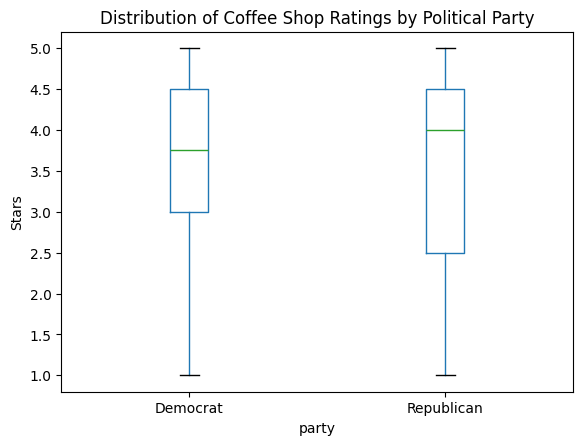

In [25]:
# visualization

import matplotlib.pyplot as plt

final_fixed.boxplot(column="stars", by="party", grid=False)
plt.title("Distribution of Coffee Shop Ratings by Political Party")
plt.suptitle("")  # remove default pandas title
plt.ylabel("Stars")
plt.show()


In [26]:
# testing for significance
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# Filter for Democrat and Republican
coffee_party = final_fixed[final_fixed["party"].isin(["Democrat", "Republican"])]

# --- Descriptive statistics ---
party_stats = coffee_party.groupby("party")["stars"].describe()
print("Descriptive statistics by party:")
print(party_stats, "\n")

# --- T-test ---
dem = coffee_party.loc[coffee_party["party"] == "Democrat", "stars"].dropna()
rep = coffee_party.loc[coffee_party["party"] == "Republican", "stars"].dropna()

t_stat, p_val = stats.ttest_ind(dem, rep, equal_var=False)  # Welch’s t-test (does not assume equal variance)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("✅ The difference in average star ratings between Democrat and Republican counties is statistically significant.")
else:
    print("❌ No statistically significant difference found between Democrat and Republican counties.")


Descriptive statistics by party:
             count      mean       std  min  25%   50%  75%  max
party                                                           
Democrat    4158.0  3.525373  0.996635  1.0  3.0  3.75  4.5  5.0
Republican  2167.0  3.496308  1.061796  1.0  2.5  4.00  4.5  5.0 

T-statistic: 1.055
P-value: 0.2915
❌ No statistically significant difference found between Democrat and Republican counties.


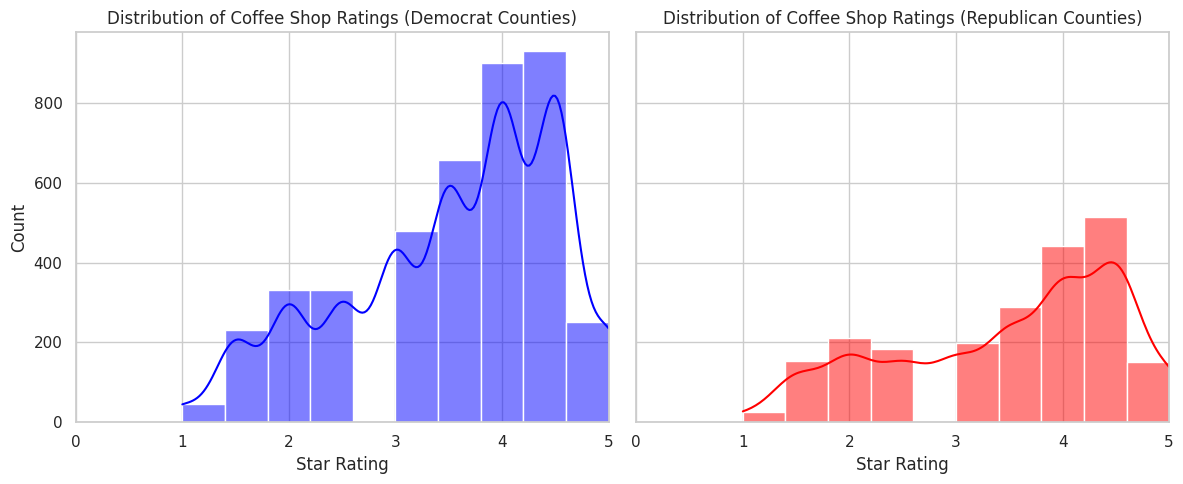

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only Democrat and Republican
coffee_party = final_fixed[final_fixed["party"].isin(["Democrat", "Republican"])]

# Set visual style
sns.set(style="whitegrid")

# --- Create subplots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Democrat distribution
sns.histplot(
    data=coffee_party[coffee_party["party"] == "Democrat"],
    x="stars", bins=10, kde=True, color="blue", ax=axes[0]
)
axes[0].set_title("Distribution of Coffee Shop Ratings (Democrat Counties)")
axes[0].set_xlabel("Star Rating")
axes[0].set_ylabel("Count")
axes[0].set_xlim(0, 5)

# Republican distribution
sns.histplot(
    data=coffee_party[coffee_party["party"] == "Republican"],
    x="stars", bins=10, kde=True, color="red", ax=axes[1]
)
axes[1].set_title("Distribution of Coffee Shop Ratings (Republican Counties)")
axes[1].set_xlabel("Star Rating")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 5)

plt.tight_layout()
plt.show()



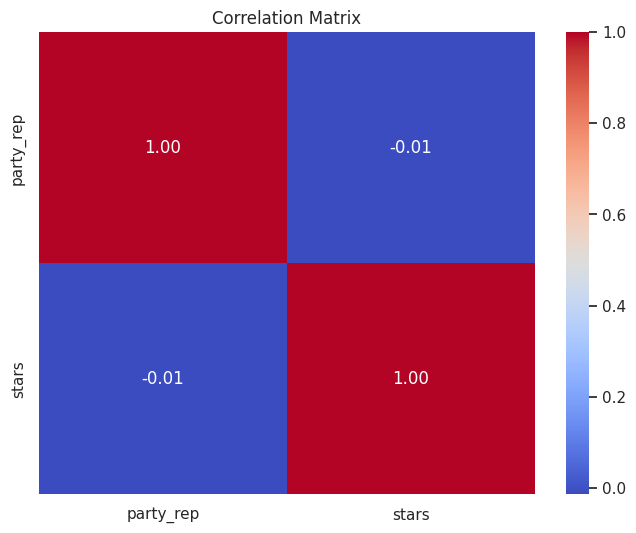

In [28]:
df = final_fixed.copy()

df['party_rep'] = df['party'].map({'Democrat': 0, 'Republican': 1})
main = df[['party_rep','stars']]
correlation_matrix = main.corr()
# print(correlation_matrix)
plt.figure(figsize=(8, 6)) # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

stars           1.000000
review_count    0.168436
party_rep      -0.013532
latitude       -0.028921
longitude      -0.077482
county_fips    -0.164944
is_open        -0.176802
Name: stars, dtype: float64


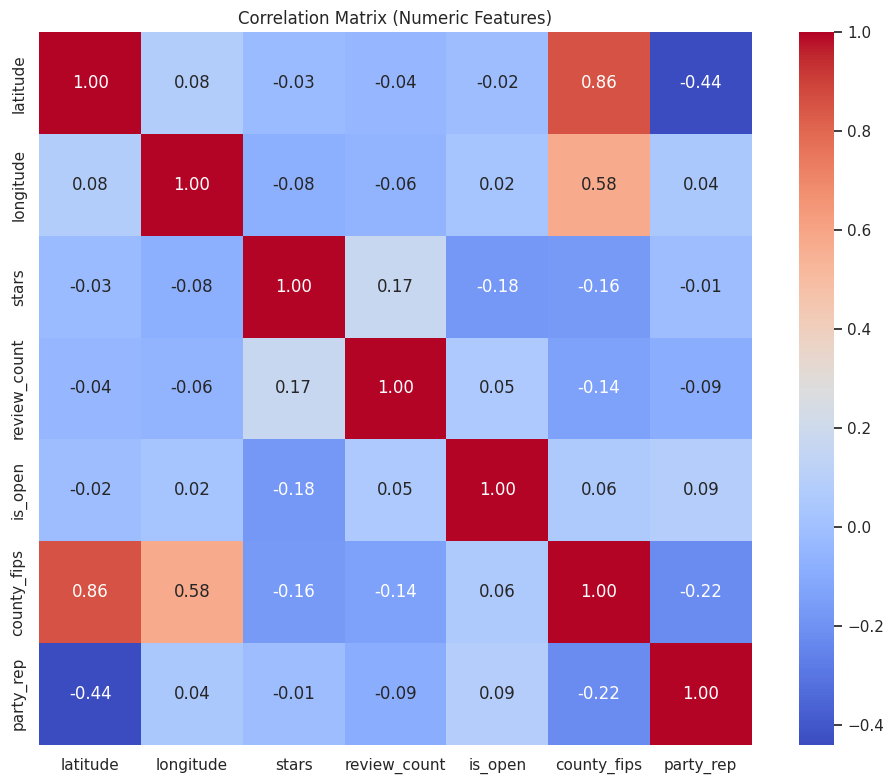

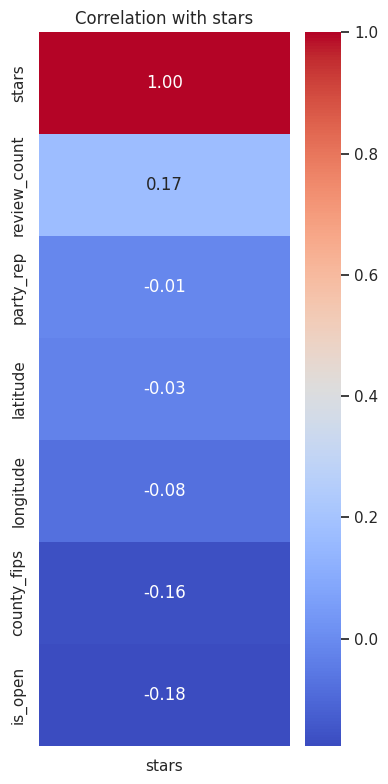

In [29]:
import pandas as pd
df = final_fixed.copy()

df['party_rep'] = df['party'].map({'Democrat': 0, 'Republican': 1})
# If your DataFrame is final_fixed
num_df = df.select_dtypes(include='number')   # keep numeric columns only

corr_matrix = num_df.corr()   # Pearson correlations by default
corr_matrix
corr_with_coffee = corr_matrix['stars'].sort_values(ascending=False)
print(corr_with_coffee)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()
target_col = 'stars'  # or 'coffee_rating'
corr_target = corr_matrix[[target_col]].sort_values(by=target_col, ascending=False)

plt.figure(figsize=(4, 8))
sns.heatmap(corr_target, annot=True, fmt=".2f", cmap='coolwarm')
plt.title(f"Correlation with {target_col}")
plt.tight_layout()
plt.show()
